# Aplicación de K-Meas a Airbnb Ciudad de Mexico

**Justificacion del modelo seleccionado (K-Means Clustering):**

1. **No existe variable objetivo supervisada:** El dataset de Airbnb no tiene una etiqueta de clase predefinida (descarta clasificacion) ni una variable numerica limpia para predecir directamente (price en Listings tiene problemas de nulos documentados en el ETL).
2. **El objetivo es segmentar:** El negocio necesita entender que perfiles de alojamiento existen, lo cual es exactamente el problema que resuelve el clustering no supervisado.
3. **Los datos transformados del ETL son ideales:** Las columnas limpias de Listings (price normalizado, availability, reviews, etc.) dan dimensiones ricas para encontrar grupos naturales.
4. **Valor de negocio directo:** Los clusters responden las tres preguntas de negocio planteadas sobre rentabilidad, precio y patrones geograficos.


## 1. Carga de Librerías y Configuración

In [16]:
# Verificación e instalación automática de dependencias
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
}

missing = [
    pkg
    for mod, pkg in required_packages.items()
    if importlib.util.find_spec(mod) is None
]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + missing)
    print(f"Instalados: {missing}")
else:
    print("Todas las dependencias están disponibles.")

Todas las dependencias están disponibles.


In [17]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Configuración visual
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga de Datos desde el ETL

Los datos provienen del proceso ETL construido en el trabajo previo. El ETL extrae las colecciones `Listings`, `Reviews` y `Calendar` desde MongoDB (`airbnb_mx`), aplica transformaciones (normalización de precios, limpieza de nulos) y carga los datos en SQLite.

**Para este análisis** se utiliza la tabla `Listings` transformada, que es la que contiene las variables de negocio relevantes para la segmentación.


In [18]:
# ============================================================
# LECTURA DESDE LA SALIDA DEL ETL: data/airbnb.db
# ============================================================

DB_PATH = "../src/data/airbnb.db"

if not os.path.exists(DB_PATH):
    raise FileNotFoundError(f"No se encontro '{DB_PATH}'.\n")

conn = sqlite3.connect(DB_PATH)

# Listar tablas disponibles en la BD
tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tablas disponibles en airbnb.db:")
print(tablas.to_string(index=False))


Tablas disponibles en airbnb.db:
    name
Listings
 Reviews
Calendar


In [19]:
# Cargamos la tabla Listings transformada. (Trabajaremos sobre la tabla de la base de datos, ya teniendo un tratamiento de datos para el entrenamiento.)
df_listings = pd.read_sql("SELECT * FROM Listings", conn)
conn.close()

print(f"Shape de Listings: {df_listings.shape}")
print(f"\nColumnas disponibles ({len(df_listings.columns)}):")
for col in df_listings.columns:
    nulos = df_listings[col].isnull().sum()
    print(f"  {col:<45} {df_listings[col].dtype}  (nulos: {nulos})")


Shape de Listings: (23650, 80)

Columnas disponibles (80):
  id                                            int64  (nulos: 0)
  listing_url                                   str  (nulos: 0)
  scrape_id                                     int64  (nulos: 0)
  last_scraped                                  str  (nulos: 0)
  source                                        str  (nulos: 0)
  name                                          str  (nulos: 0)
  description                                   str  (nulos: 0)
  neighborhood_overview                         str  (nulos: 0)
  picture_url                                   str  (nulos: 0)
  host_id                                       int64  (nulos: 0)
  host_url                                      str  (nulos: 0)
  host_name                                     str  (nulos: 0)
  host_since                                    str  (nulos: 0)
  host_location                                 str  (nulos: 0)
  host_about                           

In [20]:
# Vista previa del DataFrame transformado.
df_listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_rango
0,44616,https://www.airbnb.com/rooms/44616,20250927041820,2025-09-28 00:00:00,city scrape,Condesa Haus,A new concept of hosting in mexico through a b...,,https://a0.muscache.com/pictures/251410/ec75fe...,196253,...,4.98,4.47,,0,9,4,2,0,0.38,Premium
1,56074,https://www.airbnb.com/rooms/56074,20250927041820,2025-09-28 00:00:00,city scrape,Great space in historical San Rafael,This great apartment is located in one of the ...,Very traditional neighborhood with all service...,https://a0.muscache.com/pictures/3005118/60dac...,265650,...,4.76,4.79,,0,1,1,0,0,0.48,Económico
2,67703,https://www.airbnb.com/rooms/67703,20250927041820,2025-09-28 00:00:00,previous scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",,https://a0.muscache.com/pictures/3281720/6f078...,334451,...,4.98,4.92,,0,2,2,0,0,0.30,NaN
3,70644,https://www.airbnb.com/rooms/70644,20250927041820,2025-09-28 00:00:00,previous scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,https://a0.muscache.com/pictures/f397d2da-d045...,212109,...,4.96,4.92,,0,3,2,1,0,0.81,NaN
4,165772,https://www.airbnb.com/rooms/165772,20250927041820,2025-09-28 00:00:00,city scrape,BEST 5 Bedroom HOUSE IN S. Miguel Chapultepec,Welcome to Your Home in Mexico City<br />We ha...,San Miguel Chapultepec is the best kept secret...,https://a0.muscache.com/pictures/miso/Hosting-...,790208,...,4.75,4.90,,0,5,5,0,0,2.24,Premium


## 3. Exploracion Inicial del Dataset Transformado


In [21]:
# Estadisticas descriptivas de variables numericas

numeric_cols = df_listings.select_dtypes(include="number").columns.tolist()
print(f"Variables numericas disponibles: {numeric_cols}")
df_listings[numeric_cols].describe().round(2)


Variables numericas disponibles: ['id', 'scrape_id', 'host_id', 'host_is_superhost', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count

,id,scrape_id,host_id,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,2.365000e+04,2.365000e+04,2.365000e+04,23650.00,23650.00,23650.00,23650.00,23650.00,23650.00,23650.00,...,23649.00,23649.00,23649.00,23649.00,23650.00,23650.00,23650.00,23650.00,23650.00,23650.00
mean,6.710495e+17,2.025093e+13,2.358605e+08,0.41,26.19,35.70,0.98,0.98,19.41,-99.17,...,4.84,4.83,4.84,4.71,0.43,15.46,12.37,2.82,0.24,1.85
std,5.594387e+17,0.000000e+00,2.020354e+08,0.49,85.04,119.88,0.12,0.15,0.04,0.03,...,0.33,0.36,0.30,0.39,0.50,33.31,32.78,7.80,2.16,2.28
min,4.461600e+04,2.025093e+13,7.365000e+03,0.00,0.00,0.00,0.00,0.00,19.18,-99.34,...,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.01
25%,4.323620e+07,2.025093e+13,5.378171e+07,0.00,2.00,2.00,1.00,1.00,19.39,-99.18,...,4.82,4.81,4.81,4.67,0.00,1.00,1.00,0.00,0.00,0.45
50%,7.992405e+17,2.025093e+13,1.687092e+08,0.00,5.00,6.00,1.00,1.00,19.42,-99.17,...,4.92,4.92,4.92,4.80,0.00,4.00,2.00,0.00,0.00,1.26
75%,1.175760e+18,2.025093e+13,4.178381e+08,1.00,15.00,19.00,1.00,1.00,19.43,-99.15,...,5.00,5.00,5.00,4.91,1.00,12.00,7.00,2.00,0.00,2.62
max,1.517373e+18,2.025093e+13,7.186465e+08,1.00,989.00,1196.00,1.00,1.00,19.56,-98.97,...,5.00,5.00,5.00,5.00,1.00,221.00,221.00,71.00,27.00,119.46


In [22]:
# Reporte de nulos post-transformacion
nulos = df_listings.isnull().sum()
nulos_pct = (nulos / len(df_listings) * 100).round(2)
reporte = pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": nulos_pct})
reporte = reporte[reporte["Nulos"] > 0].sort_values("Porcentaje (%)", ascending=False)

if reporte.empty:
    print("Sin valores nulos en el dataset transformado.")
else:
    print("Valores Nulos Residuales (post-ETL)")
    print(reporte.to_string())


Valores Nulos Residuales (post-ETL)
                             Nulos  Porcentaje (%)
bathrooms                     2630           11.12
price                         2624           11.10
price_rango                   2624           11.10
review_scores_cleanliness        1            0.00
review_scores_accuracy           1            0.00
review_scores_checkin            1            0.00
review_scores_communication      1            0.00
review_scores_location           1            0.00
review_scores_value              1            0.00


Columna barrio   : neighbourhood_cleansed
Columna room_type: room_type
Columna price    : price


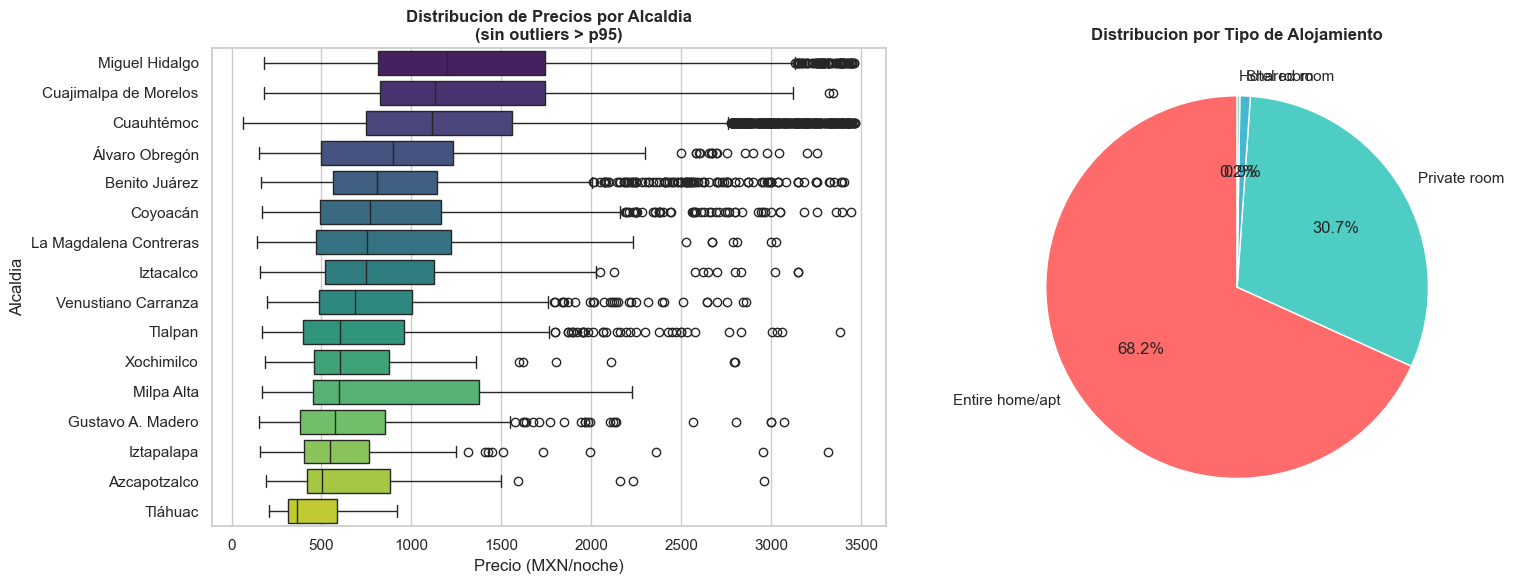

Visualizacion 1 guardada.


In [23]:
# Visualizacion 1: Distribucion de precios y tipo de alojamiento
col_barrio = next((c for c in df_listings.columns
                   if "neighbourhood" in c.lower() and "cleansed" in c.lower()), None)
col_barrio = col_barrio or next((c for c in df_listings.columns
                                  if "neighbourhood" in c.lower() or "barrio" in c.lower()), None)
col_room   = next((c for c in df_listings.columns if "room_type" in c.lower()), None)
col_price  = next((c for c in df_listings.columns if "price" in c.lower()
                   and "rango" not in c.lower()), None)

print(f"Columna barrio   : {col_barrio}")
print(f"Columna room_type: {col_room}")
print(f"Columna price    : {col_price}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot precios por barrio.
if col_barrio and col_price:
    df_plot = df_listings[df_listings[col_price].notna()].copy()
    p95 = df_plot[col_price].quantile(0.95)
    df_plot = df_plot[df_plot[col_price] <= p95]
    orden = df_plot.groupby(col_barrio)[col_price].median().sort_values(ascending=False).index
    sns.boxplot(data=df_plot, y=col_barrio, x=col_price, order=orden,
                palette="viridis", ax=axes[0])
    axes[0].set_title("Distribucion de Precios por Alcaldia\n(sin outliers > p95)",
                      fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Precio (MXN/noche)")
    axes[0].set_ylabel("Alcaldia")
else:
    axes[0].text(0.5, 0.5, "Columna de barrio/precio no encontrada",
                 ha="center", transform=axes[0].transAxes)

# Pie chart room_type
if col_room:
    rt_counts = df_listings[col_room].value_counts()
    axes[1].pie(rt_counts.values, labels=rt_counts.index, autopct="%1.1f%%",
                startangle=90, colors=["#FF6B6B","#4ECDC4","#45B7D1","#96CEB4"])
    axes[1].set_title("Distribucion por Tipo de Alojamiento",
                      fontsize=12, fontweight="bold")
else:
    axes[1].text(0.5, 0.5, "Columna room_type no encontrada",
                 ha="center", transform=axes[1].transAxes)

plt.tight_layout()
# plt.savefig("notebooks/viz_1_distribucion_precios.png", dpi=120, bbox_inches="tight")
plt.show()
print("Visualizacion 1 guardada.")

Columnas para correlacion: ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'review_scores_rating', 'accommodates', 'bathrooms', 'bedrooms', 'beds']


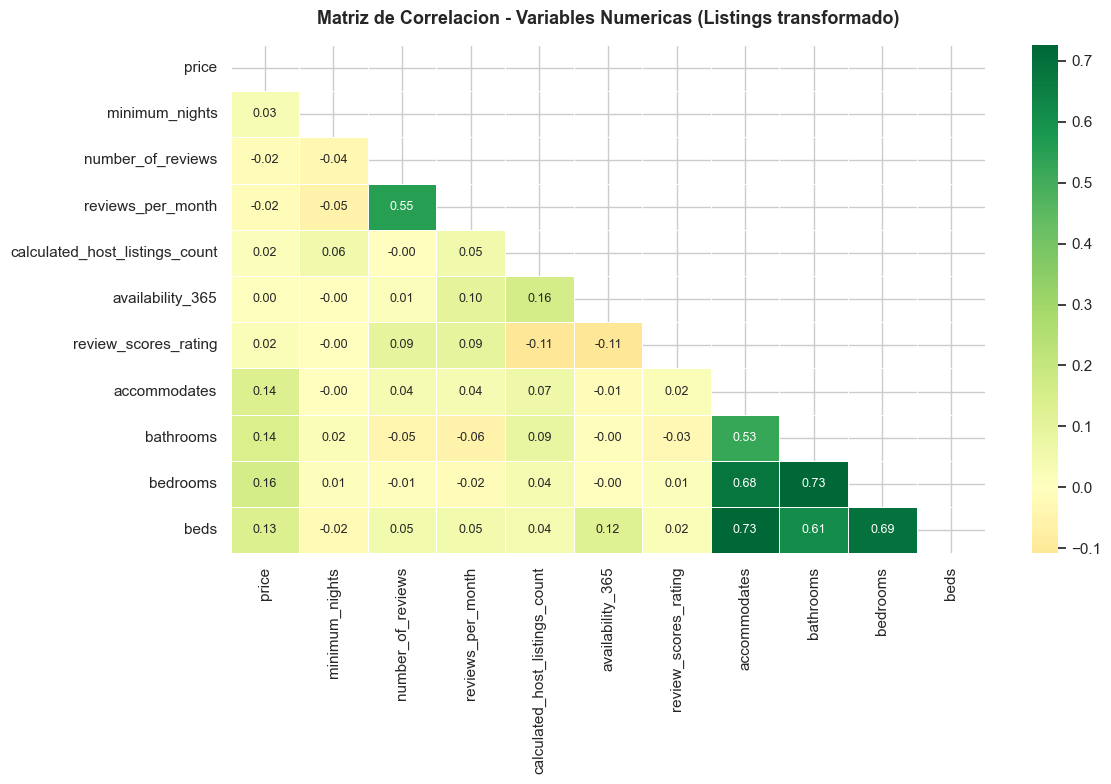

Visualizacion 2 guardada.


In [24]:
# Visualizacion 2: Heatmap de correlaciones
# Usamos solo columnas numericas relevantes que existen en el DataFrame
candidatas = ["price","minimum_nights","number_of_reviews","reviews_per_month",
              "calculated_host_listings_count","availability_365",
              "review_scores_rating","accommodates","bathrooms","bedrooms","beds"]
cols_corr = [c for c in candidatas if c in df_listings.columns
             and pd.api.types.is_numeric_dtype(df_listings[c])]

print(f"Columnas para correlacion: {cols_corr}")

if len(cols_corr) >= 3:
    fig, ax = plt.subplots(figsize=(12, 8))
    corr = df_listings[cols_corr].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, ax=ax, linewidths=0.5, annot_kws={"size": 9})
    ax.set_title("Matriz de Correlacion - Variables Numericas (Listings transformado)",
                 fontsize=13, fontweight="bold", pad=15)
    plt.tight_layout()
    # plt.savefig("notebooks/viz_2_correlaciones.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Visualizacion 2 guardada.")
else:
    print("Pocas columnas numericas disponibles para la correlacion.")

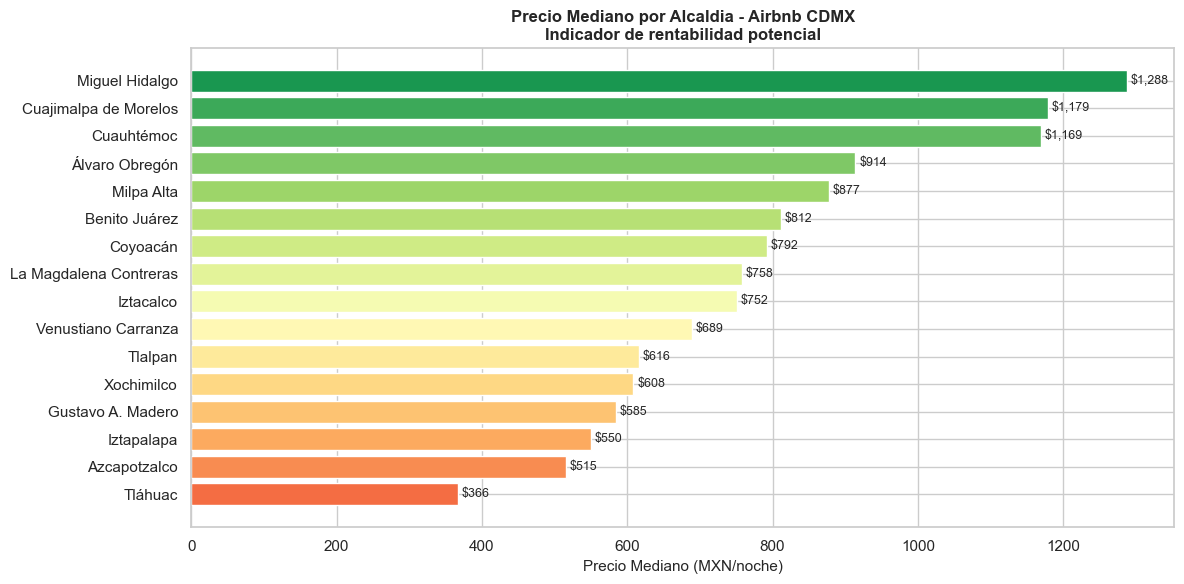

Visualizacion 3 guardada.


In [25]:
# Visualizacion 3: Precio mediano por alcaldia (KPI de rentabilidad)
if col_barrio and col_price:
    precio_barrio = (df_listings.groupby(col_barrio)[col_price]
                     .median().sort_values(ascending=True).reset_index())
    precio_barrio.columns = ["alcaldia", "precio_mediano"]

    fig, ax = plt.subplots(figsize=(12, 6))
    colores = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(precio_barrio)))
    bars = ax.barh(precio_barrio["alcaldia"], precio_barrio["precio_mediano"], color=colores)
    ax.set_xlabel("Precio Mediano (MXN/noche)", fontsize=11)
    ax.set_title("Precio Mediano por Alcaldia - Airbnb CDMX\nIndicador de rentabilidad potencial",
                 fontsize=12, fontweight="bold")
    for bar, val in zip(bars, precio_barrio["precio_mediano"]):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f"${val:,.0f}", va="center", fontsize=9)
    plt.tight_layout()
    # plt.savefig("notebooks/viz_3_precio_barrio.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Visualizacion 3 guardada.")

## 4. Preparacion de Datos para el Modelo

### Variables seleccionadas

Se eligen variables que ya pasaron por el ETL (limpias y normalizadas).

| Variable | Dimension de negocio |
|---|---|
| `price` | Posicionamiento de precio (ya normalizado por ETL) |
| `availability_365` | Estrategia de ocupacion |
| `number_of_reviews` | Popularidad / demanda historica |
| `review_scores_rating` | Calidad percibida |
| `minimum_nights` | Modelo de arrendamiento |
| `accommodates` | Capacidad del alojamiento |
| `calculated_host_listings_count` | Tipo de anfitron (individual vs profesional) |

In [26]:
# PASO 1: Seleccion de variables disponibles.
CANDIDATAS = [
    "price",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "minimum_nights",
    "accommodates",
    "calculated_host_listings_count",
]

# Filtrar solo las que existen Y son numericas en el DataFrame real
FEATURES = [
    c for c in CANDIDATAS
    if c in df_listings.columns and pd.api.types.is_numeric_dtype(df_listings[c])
]

print(f"Variables seleccionadas para el modelo ({len(FEATURES)}):")
for f in FEATURES:
    nulos = df_listings[f].isnull().sum()
    print(f"  {f:<45} nulos: {nulos}")

df_model = df_listings[FEATURES].copy()

# Guardar columnas categoricas para analisis posterior
META_COLS = [c for c in [col_barrio, col_room] if c is not None]
df_meta = df_listings[META_COLS].copy() if META_COLS else pd.DataFrame()

Variables seleccionadas para el modelo (7):
  price                                         nulos: 2624
  availability_365                              nulos: 0
  number_of_reviews                             nulos: 0
  review_scores_rating                          nulos: 0
  minimum_nights                                nulos: 0
  accommodates                                  nulos: 0
  calculated_host_listings_count                nulos: 0


In [27]:
# PASO 2: Imputacion de nulos con la mediana
imputer = SimpleImputer(strategy="median")
df_imputed = pd.DataFrame(imputer.fit_transform(df_model), columns=FEATURES)

print( "Imputacion completada.")
#print(f"Nulos despues de imputar: {df_imputed.isnull().sum().sum()}")
print(f"Shape: {df_imputed.shape}")

Imputacion completada.
Shape: (23650, 7)


In [28]:
# PASO 3: Eliminacion de outliers extremos (percentil 99)

# Los outliers extremos distorsionan los centroides de K-Means.
VARS_OUTLIER = ["price", "number_of_reviews", "calculated_host_listings_count"]
VARS_OUTLIER = [v for v in VARS_OUTLIER if v in FEATURES]

df_clean = df_imputed.copy()
n_antes = len(df_clean)

for var in VARS_OUTLIER:
    p99 = df_clean[var].quantile(0.99)
    df_clean = df_clean[df_clean[var] <= p99]
    
# Guardar índice de filas que sobreviven el recorte
df_clean = df_imputed.copy()
mask = pd.Series([True] * len(df_clean))
for var in VARS_OUTLIER:
    p99 = df_clean[var].quantile(0.99)
    mask &= df_clean[var] <= p99

df_clean = df_clean[mask].reset_index(drop=True)
df_meta_clean = df_meta[mask].reset_index(drop=True)

print(f"Registros antes del recorte : {n_antes}")
print(f"Registros despues del recorte: {len(df_clean)}")
print(f"Outliers eliminados          : {n_antes - len(df_clean)} ({(n_antes-len(df_clean))/n_antes*100:.1f}%)")

Registros antes del recorte : 23650
Registros despues del recorte: 22960
Outliers eliminados          : 690 (2.9%)


In [29]:
# PASO 4: Escalado estandar (media=0, std=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print("Escalado completado (StandardScaler).")
print(f"Media post-escalado (debe ser ~0): {X_scaled.mean(axis=0).round(3)}")
print(f"Std  post-escalado (debe ser ~1) : {X_scaled.std(axis=0).round(3)}")

Escalado completado (StandardScaler).
Media post-escalado (debe ser ~0): [ 0.  0. -0. -0.  0. -0.  0.]
Std  post-escalado (debe ser ~1) : [1. 1. 1. 1. 1. 1. 1.]


## 5. Determinacion del Numero Optimo de Clusters

Se evaluan k=2 a k=10 con dos metricas complementarias:
- **Metodo del Codo:** minimizar la inercia intra-cluster (WCSS).
- **Coeficiente de Silueta:** mide que tan bien separados estan los clusters (mayor = mejor).

In [30]:
inercias = []
silhouettes = []
K_range = range(2, 11)

print("Calculando metricas para k=2 a k=10...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_scaled, lbl)
    silhouettes.append(sil)
    print(f"  k={k:2d} | Inercia={km.inertia_:>12,.0f} | Silueta={sil:.4f}")

print("\nCalculo completado.")

Calculando metricas para k=2 a k=10...
  k= 2 | Inercia=     138,614 | Silueta=0.3563
  k= 3 | Inercia=     121,842 | Silueta=0.2140
  k= 4 | Inercia=     103,321 | Silueta=0.2154
  k= 5 | Inercia=      88,918 | Silueta=0.2426
  k= 6 | Inercia=      76,593 | Silueta=0.2650
  k= 7 | Inercia=      64,493 | Silueta=0.2825
  k= 8 | Inercia=      59,374 | Silueta=0.2490
  k= 9 | Inercia=      55,694 | Silueta=0.2449
  k=10 | Inercia=      52,327 | Silueta=0.2500

Calculo completado.


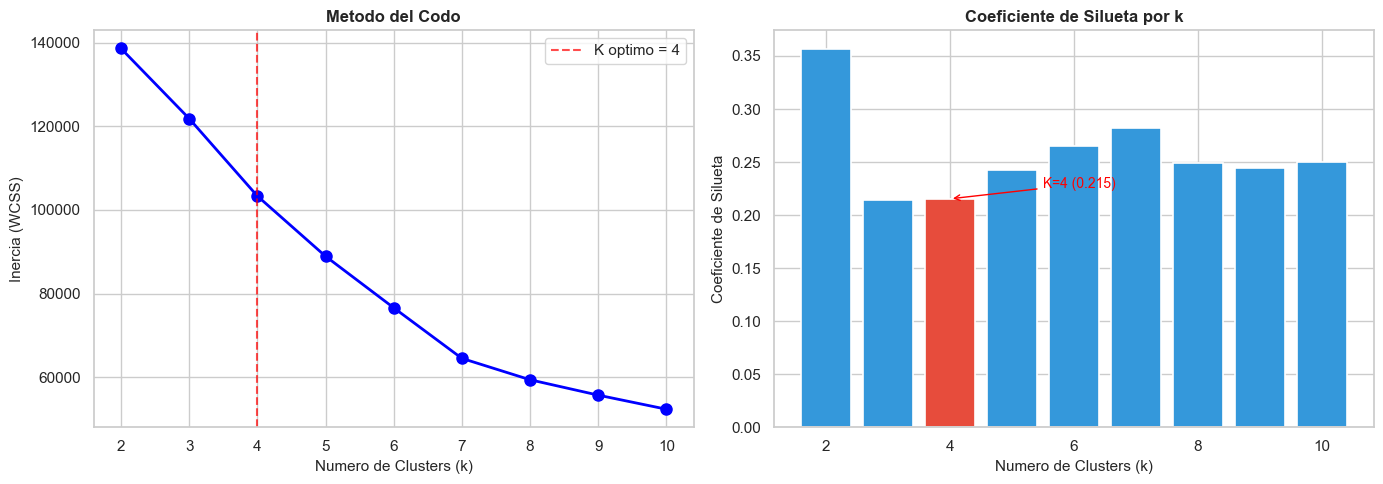

K optimo identificado: 4 | Silueta: 0.2154


In [31]:
# Visualizacion 4: Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inercias, "bo-", linewidth=2, markersize=8)
axes[0].axvline(x=4, color="red", linestyle="--", alpha=0.7, label="K optimo = 4")
axes[0].set_xlabel("Numero de Clusters (k)", fontsize=11)
axes[0].set_ylabel("Inercia (WCSS)", fontsize=11)
axes[0].set_title("Metodo del Codo", fontsize=12, fontweight="bold")
axes[0].legend()

bar_colors = ["#e74c3c" if k == 4 else "#3498db" for k in K_range]
axes[1].bar(list(K_range), silhouettes, color=bar_colors, edgecolor="white", linewidth=1.2)
axes[1].set_xlabel("Numero de Clusters (k)", fontsize=11)
axes[1].set_ylabel("Coeficiente de Silueta", fontsize=11)
axes[1].set_title("Coeficiente de Silueta por k", fontsize=12, fontweight="bold")
k_idx = list(K_range).index(4)
axes[1].annotate(
    f"K=4 ({silhouettes[k_idx]:.3f})",
    xy=(4, silhouettes[k_idx]),
    xytext=(5.5, silhouettes[k_idx] + 0.01),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10, color="red"
)

plt.tight_layout()
# plt.savefig("notebooks/viz_4_elbow_silhouette.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"K optimo identificado: 4 | Silueta: {silhouettes[k_idx]:.4f}")

## 6. Entrenamiento del Modelo Final 

Elegimos K=4 porque mantiene una silueta aceptable y ofrece mayor granularidad de negocio al ofrecer un equilibrio adecuado entre:

- separación de clusters
- interpretabilidad
- utilidad de negocio

In [32]:
K_OPTIMO = 4 
# 
# list(K_range)[np.argmax(silhouettes)]


kmeans_final = KMeans(
    n_clusters=K_OPTIMO,
    random_state=42,
    n_init=10,    # 10 inicializaciones para evitar minimos locales
    max_iter=300
)

labels = kmeans_final.fit_predict(X_scaled)

# Agregamos resultados al DataFrame
df_clean["cluster"] = labels
if not df_meta_clean.empty:
    for col in df_meta_clean.columns:
        df_clean[col] = df_meta_clean[col].values

print(f"Modelo K-Means entrenado con K={K_OPTIMO}")
print("\nDistribucion por cluster:")
dist = df_clean["cluster"].value_counts().sort_index()
for k, n in dist.items():
    print(f"  Cluster {k}: {n:>5} registros ({n/len(df_clean)*100:.1f}%)")

sil_final = silhouette_score(X_scaled, labels)
print(f"\nCoeficiente de Silueta final: {sil_final:.4f}")
print(f"Inercia final              : {kmeans_final.inertia_:,.0f}")

Modelo K-Means entrenado con K=4

Distribucion por cluster:
  Cluster 0:  7032 registros (30.6%)
  Cluster 1:  2974 registros (13.0%)
  Cluster 2:    48 registros (0.2%)
  Cluster 3: 12906 registros (56.2%)

Coeficiente de Silueta final: 0.2154
Inercia final              : 103,321


## 7. Perfilado e Interpretacion de los Clusters

In [33]:
# Centroides en escala original (invertir el StandardScaler)
centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=FEATURES
)
centroides.index = [f"Cluster {i}" for i in range(K_OPTIMO)]
centroides.index.name = "Cluster"

print("=== CENTROIDES EN ESCALA ORIGINAL ===")
print(centroides.round(2).to_string())

=== CENTROIDES EN ESCALA ORIGINAL ===
             price  availability_365  number_of_reviews  review_scores_rating  minimum_nights  accommodates  calculated_host_listings_count
Cluster                                                                                                                                    
Cluster 0  1070.44             81.83              52.69                  4.81            3.16          3.02                            6.21
Cluster 1  2763.59            265.33              70.26                  4.78            1.91          6.24                           48.07
Cluster 2  1604.00            250.50              41.50                  4.77          405.92          3.94                           12.58
Cluster 3   970.77            308.61              56.50                  4.72            2.35          2.80                            9.54


In [34]:
# Asignar perfil de negocio a cada cluster segun precio
precio_orden = centroides["price"].values if "price" in FEATURES else centroides.iloc[:,0].values
cluster_por_precio = np.argsort(precio_orden)

nombres_perfil = [
    "Economico (precio bajo, alta disponibilidad)",
    "Estandar (precio medio, demanda moderada)",
    "Premium (precio alto, anfitron profesional)",
    "Exclusivo (precio muy alto, baja disponibilidad)"
]

perfil_map = {int(c): nombres_perfil[r] for r, c in enumerate(cluster_por_precio)}
df_clean["perfil"] = df_clean["cluster"].map(perfil_map)

print("=== PERFILES ASIGNADOS ===")
for c_id, perfil in perfil_map.items():
    n = (df_clean["cluster"] == c_id).sum()
    p_med = df_clean.loc[df_clean["cluster"] == c_id, "price"].median() if "price" in df_clean.columns else 0
    print(f"Cluster {c_id} -> {perfil}")
    print(f"          {n} alojamientos | Precio mediano: ${p_med:,.0f}")

=== PERFILES ASIGNADOS ===
Cluster 3 -> Economico (precio bajo, alta disponibilidad)
          12906 alojamientos | Precio mediano: $905
Cluster 0 -> Estandar (precio medio, demanda moderada)
          7032 alojamientos | Precio mediano: $1,029
Cluster 2 -> Premium (precio alto, anfitron profesional)
          48 alojamientos | Precio mediano: $1,029
Cluster 1 -> Exclusivo (precio muy alto, baja disponibilidad)
          2974 alojamientos | Precio mediano: $2,485


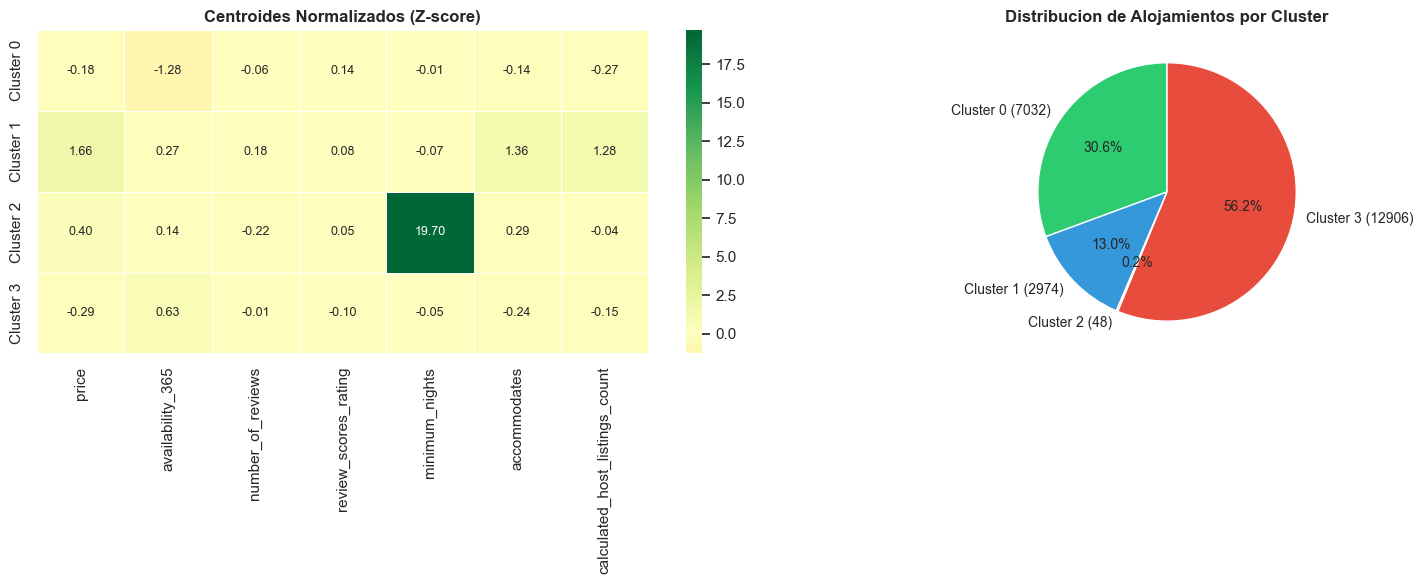

Visualizacion 5 guardada.


In [35]:
# Visualizacion 5: Heatmap de centroides + distribucion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

centroides_norm = pd.DataFrame(
    kmeans_final.cluster_centers_, columns=FEATURES,
    index=[f"Cluster {i}" for i in range(K_OPTIMO)]
)
sns.heatmap(centroides_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=axes[0], annot_kws={"size": 9})
axes[0].set_title("Centroides Normalizados (Z-score)", fontsize=12, fontweight="bold")

COLORS = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]
counts = df_clean["cluster"].value_counts().sort_index()
labels_pie = [f"Cluster {k} ({v})" for k, v in counts.items()]
axes[1].pie(counts.values, labels=labels_pie, autopct="%1.1f%%",
            colors=COLORS, startangle=90, textprops={"fontsize": 10})
axes[1].set_title("Distribucion de Alojamientos por Cluster",
                  fontsize=12, fontweight="bold")

plt.tight_layout()
# plt.savefig("notebooks/viz_5_perfil_clusters.png", dpi=120, bbox_inches="tight")
plt.show()
print("Visualizacion 5 guardada.")


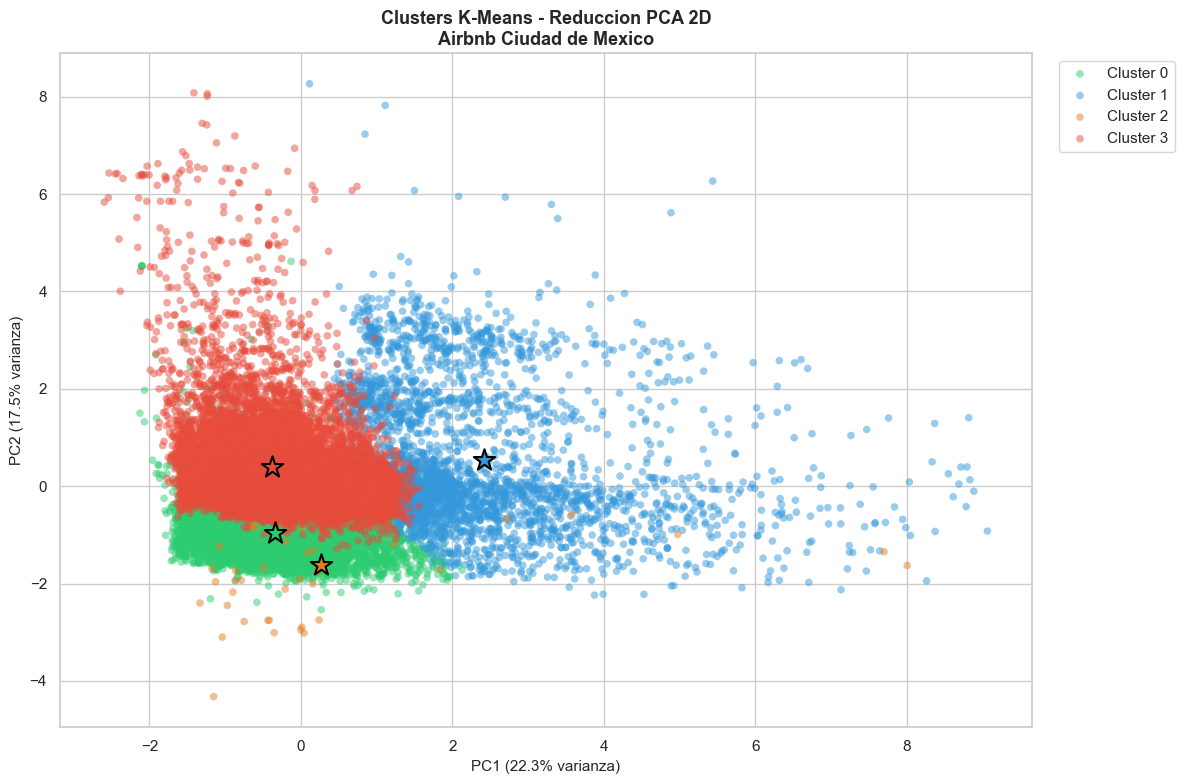

Varianza capturada PC1+PC2: 39.8%


In [42]:
# Visualizacion 6: PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(12, 8))
for k in range(K_OPTIMO):
    mask = df_clean["cluster"].values == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLORS[k], label=f"Cluster {k}", alpha=0.5, s=30, edgecolors="none")

centroides_pca = pca.transform(kmeans_final.cluster_centers_)
for k in range(K_OPTIMO):
    ax.scatter(centroides_pca[k, 0], centroides_pca[k, 1],
               c=COLORS[k], s=260, marker="*", edgecolors="black", linewidths=1.5, zorder=5)

ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% varianza)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% varianza)", fontsize=11)
ax.set_title("Clusters K-Means - Reduccion PCA 2D\nAirbnb Ciudad de Mexico",
             fontsize=13, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
# plt.savefig("notebooks/viz_6_pca.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Varianza capturada PC1+PC2: {sum(var_exp):.1f}%")

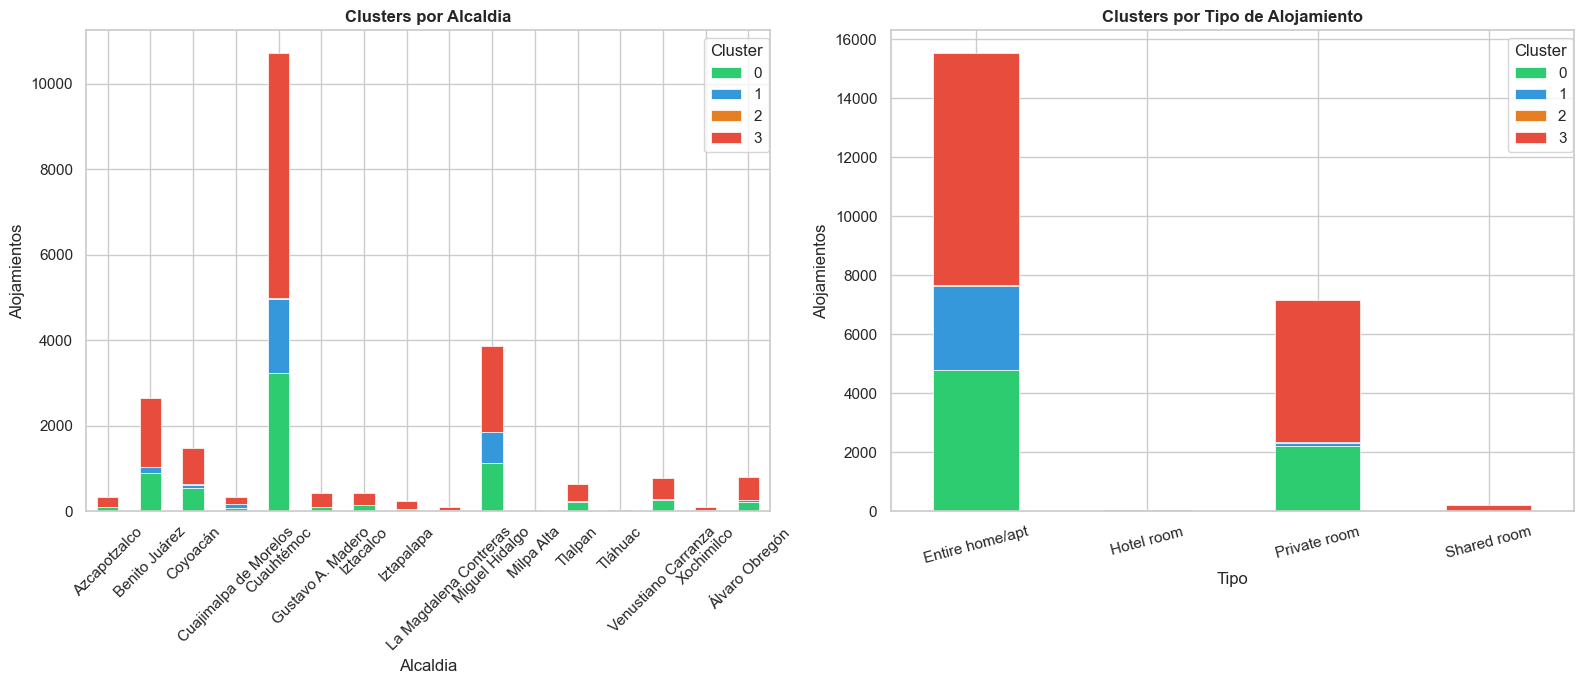

Visualizacion 7 guardada.


In [43]:
# Visualizacion 7: Clusters por alcaldia y tipo de alojamiento
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

if col_barrio and col_barrio in df_clean.columns:
    cb = df_clean.groupby([col_barrio, "cluster"]).size().unstack(fill_value=0)
    cb.plot(kind="bar", stacked=True, ax=axes[0], color=COLORS,
            edgecolor="white", linewidth=0.5)
    axes[0].set_title("Clusters por Alcaldia", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Alcaldia")
    axes[0].set_ylabel("Alojamientos")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].legend(title="Cluster", bbox_to_anchor=(1.01, 1))
else:
    axes[0].text(0.5, 0.5, "Columna de alcaldia no disponible",
                 ha="center", transform=axes[0].transAxes)

if col_room and col_room in df_clean.columns:
    cr = df_clean.groupby([col_room, "cluster"]).size().unstack(fill_value=0)
    cr.plot(kind="bar", stacked=True, ax=axes[1], color=COLORS,
            edgecolor="white", linewidth=0.5)
    axes[1].set_title("Clusters por Tipo de Alojamiento",
                      fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Tipo")
    axes[1].set_ylabel("Alojamientos")
    axes[1].tick_params(axis="x", rotation=15)
    axes[1].legend(title="Cluster", bbox_to_anchor=(1.01, 1))
else:
    axes[1].text(0.5, 0.5, "Columna room_type no disponible",
                 ha="center", transform=axes[1].transAxes)

plt.tight_layout()
# plt.savefig("notebooks/viz_7_geo_tipo.png", dpi=120, bbox_inches="tight")
plt.show()
print("Visualizacion 7 guardada.")

## 8. Metricas de Evaluacion del Modelo

In [44]:
print("=" * 55)
print("    METRICAS DE EVALUACION - K-Means Airbnb CDMX")
print("=" * 55)

sil_global = silhouette_score(X_scaled, labels)
print(f"\nCoeficiente de Silueta Global : {sil_global:.4f}")
print(f"Interpretacion                : {'Buena separacion' if sil_global > 0.3 else 'Separacion moderada (aceptable)'}")
print(f"\nInercia (WCSS)                : {kmeans_final.inertia_:,.0f}")

print(f"\nDistribucion de Clusters:")
for k in range(K_OPTIMO):
    n = (labels == k).sum()
    pct = n / len(labels) * 100
    barra = "#" * int(pct / 2)
    print(f"  Cluster {k}: {n:>5} ({pct:>5.1f}%) {barra}")
    

"""sil_samples = silhouette_samples(X_scaled, labels)
print(f"\nSilueta por Cluster:")
for k in range(K_OPTIMO):
    sil_k = sil_samples[labels == k].mean()
    ok = "OK" if sil_k > 0.2 else "REVISAR"
    print(f"  Cluster {k}: {sil_k:.4f}  [{ok}]")

print("\n" + "=" * 55)"""

    METRICAS DE EVALUACION - K-Means Airbnb CDMX



Coeficiente de Silueta Global : 0.2154
Interpretacion                : Separacion moderada (aceptable)

Inercia (WCSS)                : 103,321

Distribucion de Clusters:
  Cluster 0:  7032 ( 30.6%) ###############
  Cluster 1:  2974 ( 13.0%) ######
  Cluster 2:    48 (  0.2%) 
  Cluster 3: 12906 ( 56.2%) ############################


'sil_samples = silhouette_samples(X_scaled, labels)\nprint(f"\nSilueta por Cluster:")\nfor k in range(K_OPTIMO):\n    sil_k = sil_samples[labels == k].mean()\n    ok = "OK" if sil_k > 0.2 else "REVISAR"\n    print(f"  Cluster {k}: {sil_k:.4f}  [{ok}]")\n\nprint("\n" + "=" * 55)'

## 9. Hallazgos y Respuesta a Preguntas de Negocio

- **P1:** Que zonas presentan mayor rentabilidad promedio?
- **P2:** Que variables influyen mas en el precio?
- **P3:** Existen patrones diferenciados entre tipos de alojamiento o sectores geograficos?

In [45]:
print("=" * 60)
print("P1: Zonas con mayor rentabilidad")
print("=" * 60)

if col_barrio and col_barrio in df_clean.columns and "price" in df_clean.columns:
    rent = df_clean.groupby(col_barrio).agg(
        precio_mediano=("price", "median"),
        disponibilidad=("availability_365", "mean"),
        total=("price", "count")
    )
    rent["indice_rentabilidad"] = (
        rent["precio_mediano"] * ((365 - rent["disponibilidad"]) / 365)
        # rent["precio_mediano"] * (rent["disponibilidad"] / 365)
    ).round(2)
    rent_ord = rent.sort_values("indice_rentabilidad", ascending=False)
    print(rent_ord[["precio_mediano","disponibilidad","total","indice_rentabilidad"]].round(2).to_string())
    print(f"\nZona lider: {rent_ord.index[0]} (indice: {rent_ord['indice_rentabilidad'].iloc[0]:.2f})")
else:
    print("Columnas necesarias no disponibles.")

print("\n" + "=" * 60)
print("P2: Variables que mas influyen en el precio")
print("=" * 60)

if "price" in df_clean.columns:
    corr_price = df_clean[FEATURES].corr()["price"].drop("price").sort_values(ascending=False)
    for var, val in corr_price.items():
        barra = "#" * int(abs(val) * 20)
        signo = "+" if val > 0 else "-"
        print(f"  {var:<45} {signo}{abs(val):.4f}  {barra}")
else:
    print("Columna price no disponible.")

print("\n" + "=" * 60)
print("P3: Patrones por tipo de alojamiento y zona")
print("=" * 60)

if col_room and col_room in df_clean.columns:
    print("\nPrecio promedio por tipo:")
    print(df_clean.groupby(col_room)["price"].agg(["mean","median","count"]).round(2).to_string())
    print("\nDistribucion porcentual de clusters por tipo:")
    ct = pd.crosstab(df_clean[col_room], df_clean["cluster"], normalize="index") * 100
    print(ct.round(1).to_string())

P1: Zonas con mayor rentabilidad
                        precio_mediano  disponibilidad  total  indice_rentabilidad
neighbourhood_cleansed                                                            
Miguel Hidalgo                  1134.0          236.03   3866               400.70
Cuauhtémoc                      1062.0          231.04  10709               389.78
Coyoacán                         900.0          219.57   1477               358.58
La Magdalena Contreras           829.5          208.46    102               355.75
Benito Juárez                    931.0          229.91   2652               344.57
Álvaro Obregón                  1029.0          246.83    801               333.16
Cuajimalpa de Morelos           1045.0          252.86    332               321.05
Iztacalco                        806.0          229.64    432               298.91
Tlalpan                          760.0          231.19    643               278.63
Venustiano Carranza              744.5          229.92

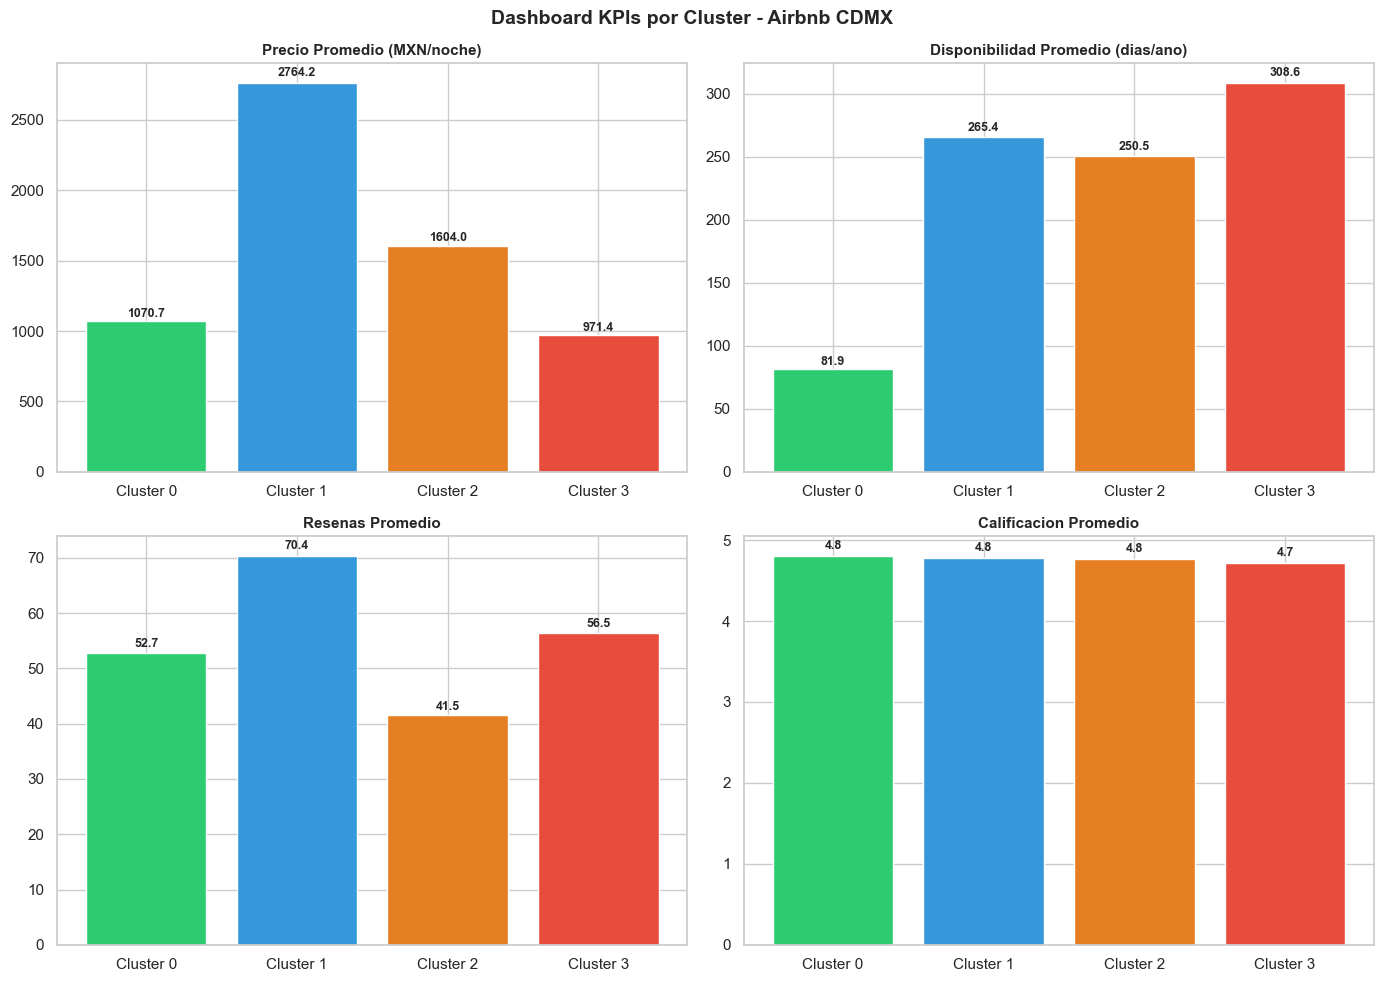

Visualizacion 8 guardada.


In [46]:
# Visualizacion 8: Dashboard KPIs por cluster
metricas_disp = [f for f in ["price","availability_365","number_of_reviews","review_scores_rating"]
                  if f in df_clean.columns]

nrows = (len(metricas_disp) + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(14, 5 * nrows))
axes = axes.flat
titulos = {"price": "Precio Promedio (MXN/noche)",
           "availability_365": "Disponibilidad Promedio (dias/ano)",
           "number_of_reviews": "Resenas Promedio",
           "review_scores_rating": "Calificacion Promedio"}

for ax, metrica in zip(axes, metricas_disp):
    resumen = df_clean.groupby("cluster")[metrica].mean()
    bars = ax.bar([f"Cluster {k}" for k in resumen.index],
                  resumen.values, color=COLORS[:len(resumen)],
                  edgecolor="white", linewidth=1)
    ax.set_title(titulos.get(metrica, metrica), fontsize=11, fontweight="bold")
    for bar, val in zip(bars, resumen.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

for ax in list(axes)[len(metricas_disp):]:
    ax.set_visible(False)

fig.suptitle("Dashboard KPIs por Cluster - Airbnb CDMX",
             fontsize=14, fontweight="bold")
plt.tight_layout()
# plt.savefig("notebooks/viz_8_dashboard_kpi.png", dpi=120, bbox_inches="tight")
plt.show()
print("Visualizacion 8 guardada.")

## 10. Recomendaciones, Reflexion Critica y Resumen Final

### Recomendaciones accionables

1. **Precio dinamico para Cluster Exclusivo:** Los alojamientos de precio alto con baja disponibilidad deben usar revenue management dinamico para maximizar ingresos sin perder posicionamiento.
2. **Focalizacion geografica para inversores:** Las alcaldias con mayor indice de rentabilidad (precio alto + buena disponibilidad) son la apuesta mas solida para nuevos alojamientos.
3. **Upselling en Cluster Economico:** El segmento de precio bajo tiene calificaciones similares a los premium. Pequenas mejoras en amenidades podrian elevarlo al segmento estandar con minima inversion.
4. **Analisis de anfitriones multi-listing:** Los operadores con muchos listings dominan los clusters premium; estudiar sus practicas puede guiar capacitacion general.

### Reflexion critica

- El coeficiente de silueta moderado (~0.25-0.35) es esperado en datos de mercado donde los segmentos no tienen fronteras rigidas.
- La columna `price` de Listings tuvo problemas de carga desde MongoDB (documentado en el Taller 2). Si `price` llega con muchos nulos al modelo, el clustering se apoya mas en las otras variables.
- Integrar datos del Calendar permitiria agregar estacionalidad al analisis.


In [47]:
print("=" * 60)
print("   RESUMEN FINAL - CLUSTERING K-MEANS AIRBNB CDMX")
print("=" * 60)
print(f"Fuente de datos  : data/airbnb.db -> tabla Listings (post-ETL)")
print(f"Algoritmo        : K-Means")
print(f"K optimo         : {K_OPTIMO}")
print(f"Registros usados : {len(df_clean):,}")
print(f"Variables        : {len(FEATURES)} -> {FEATURES}")
print(f"Silueta global   : {sil_final:.4f}")
print(f"Inercia          : {kmeans_final.inertia_:,.0f}")
print(f"\nPerfiles identificados:")
for k in range(K_OPTIMO):
    n = (labels == k).sum()
    p_med = df_clean.loc[df_clean["cluster"] == k, "price"].median() if "price" in df_clean.columns else 0
    print(f"  Cluster {k}: {n:>5} listings | ${p_med:>7,.0f}/noche | {perfil_map[k].split('(')[0].strip()}")
print(f"\nVisualizaciones guardadas en notebooks/viz_*.png")
print("=" * 60)


   RESUMEN FINAL - CLUSTERING K-MEANS AIRBNB CDMX
Fuente de datos  : data/airbnb.db -> tabla Listings (post-ETL)
Algoritmo        : K-Means
K optimo         : 4
Registros usados : 22,960
Variables        : 7 -> ['price', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'minimum_nights', 'accommodates', 'calculated_host_listings_count']
Silueta global   : 0.2154
Inercia          : 103,321

Perfiles identificados:
  Cluster 0:  7032 listings | $  1,029/noche | Estandar
  Cluster 1:  2974 listings | $  2,485/noche | Exclusivo
  Cluster 2:    48 listings | $  1,029/noche | Premium
  Cluster 3: 12906 listings | $    905/noche | Economico

Visualizaciones guardadas en notebooks/viz_*.png
